# Climate Coding Challenge

Climate change is impacting the way people live around the world



## Set up

To get started on this notebook, you’ll need to restore any variables
from previous notebooks to your workspace. To save time and memory, make
sure to specify which variables you want to load.

In [8]:
#restore variables from previous notebooks
%store -r

You will also need to import any libraries you are using in this
notebook, since they won’t carry over from the previous notebook:

In [9]:
### import libraries

### deal with local data
import earthpy

### deal with tabular data
import pandas as pd

### bring in plotting packages
import holoviews as hv
import hvplot.pandas
import hvplot

## Step 5: Quantify how fast the climate is changing with a trend line

>**Is linear OLS regression right for this data?**
>
>While our temperature data for Boulder presumably includes random variation caused by things like El Niño and La Niña, it seems a little bit unrealistic to assume that all of the variation in mean annual temperatures is random. We are looking at annual means, not maximum or minimum values, so the data is normally distributed because it doesn't really account for extremes in the same way that daily data would. Our data meets the assumption of a somewhat constant rate of temperature increase because the data was collected in Colorado, not in a place like the Arctic where rates of changes are less linear. The data may not meet the assumption of stationarity, as variability likely changes year to year depending on ocean temperatures, etc., and there may be increased year to year variability in both extreme warm and cold temperatures as a result of climate change. 

The following cell contains package imports that you will need to calculate and plot an OLS Linear trend line. Make sure to run the cell before moving on, and if you have any additional packages you would like to use, add them here later on:

In [10]:
### advanced options on matplotlib/seaborn/pandas plots
import matplotlib.pyplot as plt

### common statistical plots for tabular data
import seaborn as sns

### fit an OLS linear regression
from sklearn.linear_model import LinearRegression

In [11]:
### subset data to only include temp in Celsius
annual_temp_c_df = annual_temp_df[['temp_c']]

### subset data to 1988-2025 because 2026 isn't a full year of data
complete_data_df = annual_temp_c_df.loc['1988':'2025']
complete_data_df

,temp_c
DATE,
1988-01-01,20.823212
1989-01-01,18.045662
1990-01-01,16.569254
1991-01-01,16.340944
1992-01-01,16.564967
1993-01-01,17.310107
1994-01-01,17.568681
1995-01-01,17.512277
1996-01-01,17.846271


In [12]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
ind_variable = complete_data_df.index.year.values.reshape(-1, 1)

### define dependent variable
dep_variable = complete_data_df

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(ind_variable, dep_variable)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

Slope: [0.01996211] degrees per year


### Plot your trend line

Trend lines are often used to help your audience understand and process
a time-series plot. In this case, we’ve chosen mean temperature values
rather than extremes, so we think OLS is an appropriate model to use to
show a trend.

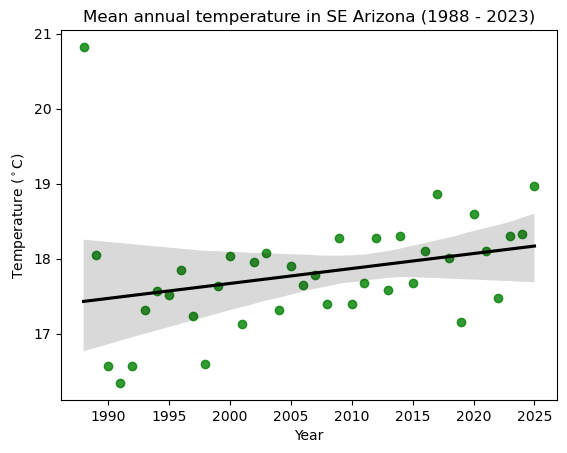

In [13]:
### plot data
ax = sns.regplot(
    x = complete_data_df.index.year, 
    y = complete_data_df.temp_c,

    ### change the color of data points
    color = 'green',

    ### change the color of the trendline
    line_kws= {'color': 'black'}
)

### make labels
ax.set(
    title = 'Mean annual temperature in SE Arizona (1988 - 2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/climate-change/arizona-climate-trendline.jpeg')

### plot it
plt.show()

>*Mean annual temperatures in Boulder, CO have increased over the last century*

>In SE Arizona, mean annual temperatures have increased by 0.012 degrees C per year from 1988 to 2025. Temperatures are likely increasing as a result of climate change, although other environmental characteristics, like trends in sea surface temperatures, may also influence some of this rate of temperature change.